# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 7</span>
### <span style= "color: black" > Es07.1

Lo scopo di questo esercizio è correggere il calcolo implementato nel file C++ `system.cpp`, utilizzato in questa esercitazione e anche nelle esercitazioni 4 e 6, per ricavare correttamente la pressione $P$ e l'energia interna per particella $U/N$.

Nell'implementazione attuale, l'interazione tra le particelle viene calcolata solo fino a un raggio di cutoff $r_{cut}$ e per distanze maggiori di $r_{cut}$ le interazioni tra particelle vengono trascurate. Questa scelta permette di ridurre il costo computazionale poiché il contributo principale del potenziale a coppie viene infatti dalle interazioni di una particella con le sue vicine.
Questa approssimazione però modifica i valori reali sia della pressione sia dell'energia interna.

Per tenere conto del contributo a lungo raggio trascurato, sono state  introdotte le seguenti **tail corrections**. Tali correzioni sono ricavate assumendo che, per distanze maggiori del raggio di cutoff, la distribuzione radiale $g(r)$ sia circa $1$ per $r > r_{cut}$.

1. $\frac{\langle U^* \rangle_{\text{tail}}}{N} = 8\pi \rho^*\left(\frac{1}{9 r_{\text{cutoff}}^{*9}}-\frac{1}{3 r_{\text{cutoff}}^{*3}}\right)$

2. $ \langle P^* \rangle_{\text{tail}} =32\pi \rho^{*2}\left(\frac{1}{9 r_{\text{cutoff}}^{*9}}-\frac{1}{6 r_{\text{cutoff}}^{*3}}\right) $

espresse in unità ridotte.

### <span style= "color: black" > Es07.2

Consideriamo ora un sistema di $108$ particelle nelle seguenti condizioni termodinamiche: 

- fase solida: $\rho^\star = 1.1$, $T^\star = 0.8$ ($r_c = 2.2$)
- fase liquida: $\rho^\star = 0.8$, $T^\star = 1.1$ ($r_c = 2.5$)
- fase gassosa: $\rho^\star = 0.05$, $T^\star = 1.2$ ($r_c = 5.0$).

Il primo passaggio è sempre l'equilibrazione del sistema. Per ciascuna fase è stata eseguita una simulazione preliminare di $N = 2000$ blocchi da $M = 10$ step Monte Carlo. Durante questa fase è stato scelto un opportuno valore del parametro di spostamento $\delta$ in modo da ottenere un'accettazione dell'algoritmo di Metropolis di circa il $50\%$. 

In particolare si ottiene un'accettazione di circa il $51\%$ per solido e liquido con rispettivamente un passo $\delta$ di $0.055$ e $0.1$. Per la fase gassosa anche per passi molto maggiori di $r_{cut}$ l'accettazione non scende sotto il $60\%$. Questo è dovuto al fatto che in un gas le particelle sono molto più diluite e quindi anche proponendo spostamenti relativamente grandi, la variazione di energia associata alla mossa è spesso piccola e la probabilità di accettazione dell'algoritmo di Metropolis rimane elevata. In questo caso è stato scelto $\delta = 4.0$ che produce un'accettazione di circa il $62\%$. Si è preferito scegliere un passo minore del raggio di cutoff ed ottenere un'accettazione più elevata ,piuttosto che scegliere valori enormi di $\delta$ ed avvicinarsi al $50\%$, poiché spostamenti troppo grandi renderebbero le mosse Monte Carlo meno locali e meno naturali per questo tipo di simulazione.

Lo scopo è quello di ricavare $5\times 10^5$ valori istantanei di $U/N$ per tutte e tre le fasi con lo scopo di studiare l'andamento dell'autocorrelazione fra le misure e dell'errore statistico in funzione della larghezza dei blocchi.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Plot either the instantaneous values or the progressive block averages
def plot(filename, y_name, color, n, steps_per_block=1, title=None, x_name=None, ax=None):
    
    data = np.loadtxt(filename, skiprows=1)

    block = data[:, 0]
    steps = block * steps_per_block
    y = data[:, n]
    error = data[:, 3]

    if title is not None:
        title = title

    # Create a new figure only when an external axis is not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 10))
        single_plot = True
    else:
        single_plot = False

    # Plot instantaneous values as a function of the simulation steps
    if n == 1:
        x = steps
        if x_name is None:
            x_name = "Simulation steps"
        ax.plot(x, y, color=color, label=y_name)

    # Plot progressive block averages with their statistical uncertainties
    elif n == 2:
        x = block
        if x_name is None:
            x_name = "Number of blocks"
        ax.errorbar(x, y, yerr=error, fmt="o-", color=color, markersize=5, label=y_name)

    ax.set_xlabel(x_name, fontsize=12)
    ax.set_ylabel(y_name, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True)

    if single_plot:
        plt.show()

Vengono qui di seguito riportati i grafici dell'equiilibrazione di $U/N$ prima per la fase solida, poi per la fase liquida ed infine per quella gassosa.
In particolare vengono riportati i valori delle medie di $U/N$ di ogni blocco in funzione del numero di steps della simulazione.

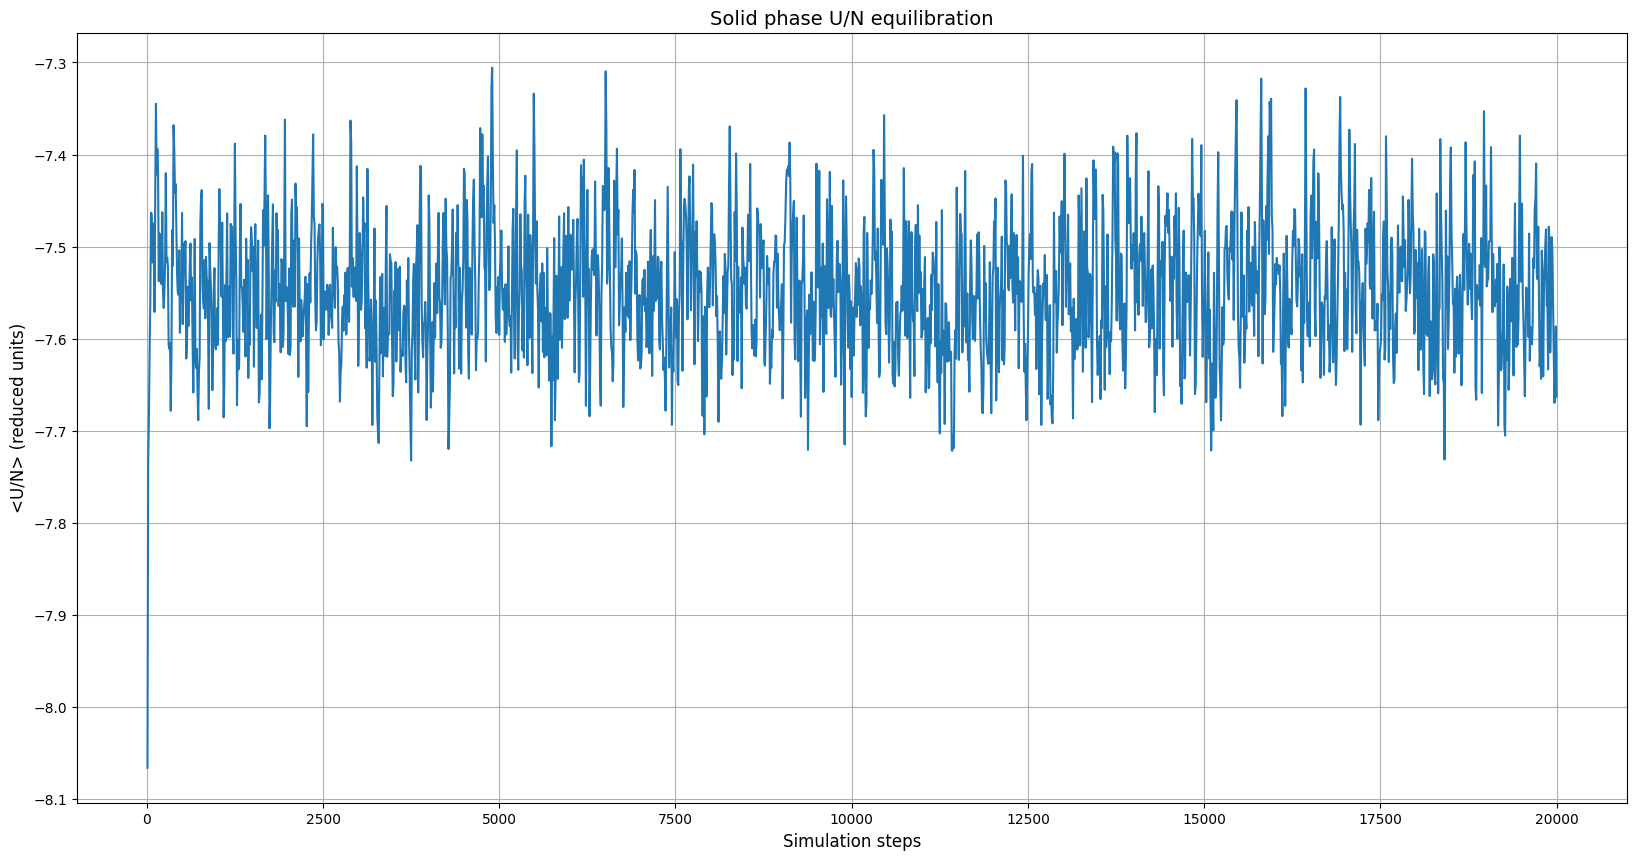

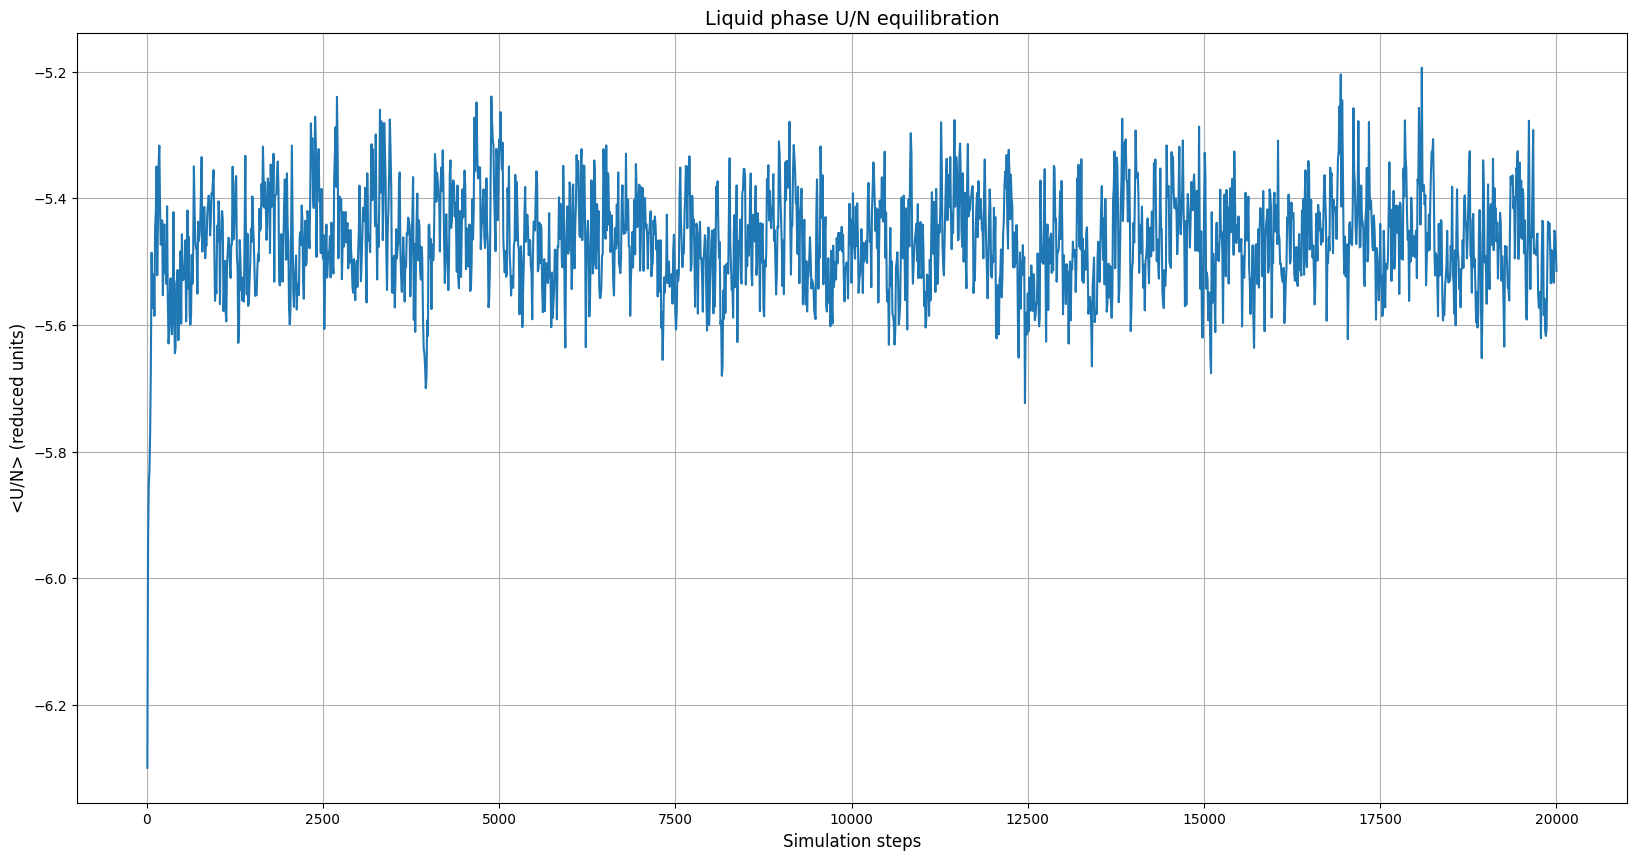

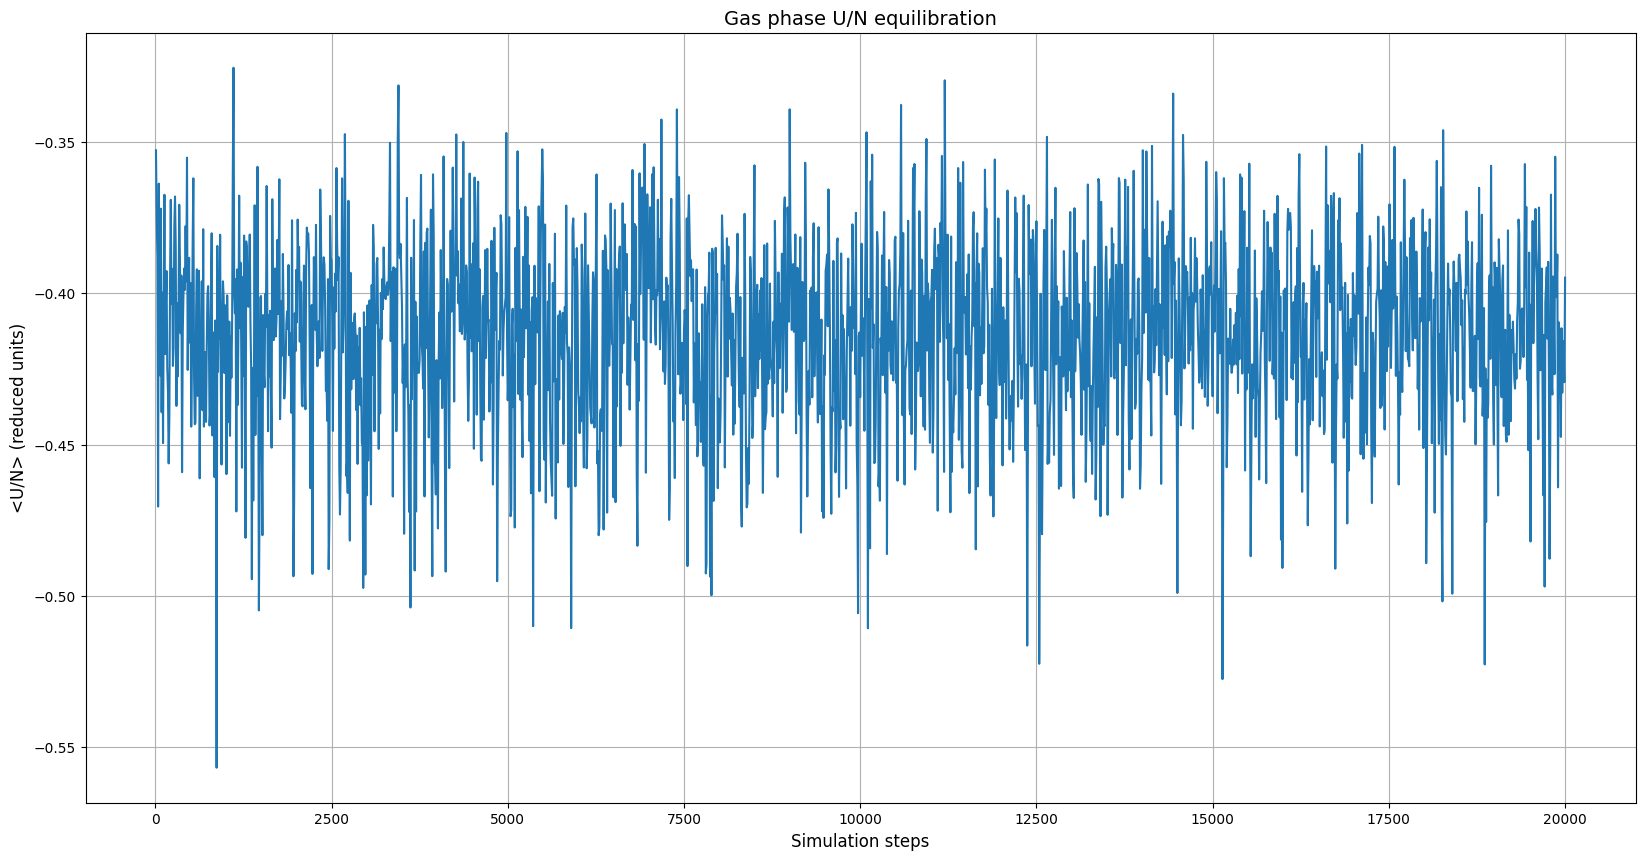

In [2]:
# Plot of <U/N> during equilibration in the three phases
plot("NSL_SIMULATOR/OUTPUT/7.2/Solid/Eq/potential_energy.dat", "<U/N> (reduced units)", "C0", 1, steps_per_block=10, title="Solid phase U/N equilibration")
plot("NSL_SIMULATOR/OUTPUT/7.2/Liquid/Eq/potential_energy.dat", "<U/N> (reduced units)", "C0", 1, steps_per_block=10, title="Liquid phase U/N equilibration")
plot("NSL_SIMULATOR/OUTPUT/7.2/Gas/Eq/potential_energy.dat", "<U/N> (reduced units)", "C0", 1, steps_per_block=10, title="Gas phase U/N equilibration")

Nel caso solido e liquido si osserva un chiaro transiente iniziale seguito da un'oscillazione attorno ad un valore medio. Nel caso gassoso questo transiente non è così evidente poiché il grafico è più rumoroso in quanto presenta oscillazioni più ampie. 

In ogni caso possiamo affermare che anche prima di $20000$ steps il sistema ha raggiunto l'equilibrio.

Dopo l'equilibrazione viene eseguita una simulazione con $N = 500000$ ed $M = 1$ in modo da estrarre i valori istantanei di $U/N$ per le tre diverse condizioni termodinamiche. 
Questi valori vengono quindi utilizzati per ricavare i valori della funzione di autocorrelazione normalizzata 

$$ C(\tau) =
\frac{
\left\langle
\left(\frac{U}{N}(t) - \left\langle \frac{U}{N} \right\rangle \right)
\left(\frac{U}{N}(t+\tau) - \left\langle \frac{U}{N} \right\rangle \right)
\right\rangle
}{
\left\langle
\left(\frac{U}{N}(t) - \left\langle \frac{U}{N} \right\rangle \right)^2
\right\rangle
} $$

calcolata con la funzione `np.correlate` applicata ai valori di $U/N$ estratti centrati nel valore medio. 

$\tau$ rappresenta il ritardo temporale fra le serie di dati considerati (*lag*).


In [3]:
# Compute the normalized autocorrelation function of the potential energy
def correlazione (filename):
    
    data = np.loadtxt(filename, skiprows=1) # Read the instantaneous values of U/N
    U = data[:, 1]  # Subtract the mean before computing the correlation
    u = U - np.mean(U) 
    corr = np.correlate(u, u, mode="full") # Compute the correlation for all possible positive and negative lags
    corr = corr[corr.size // 2:]  # Keep only non-negative lags
    corr = corr / corr[0]  # Normalize the autocorrelation so that C(0) = 1

    return corr # Return autocorrelation

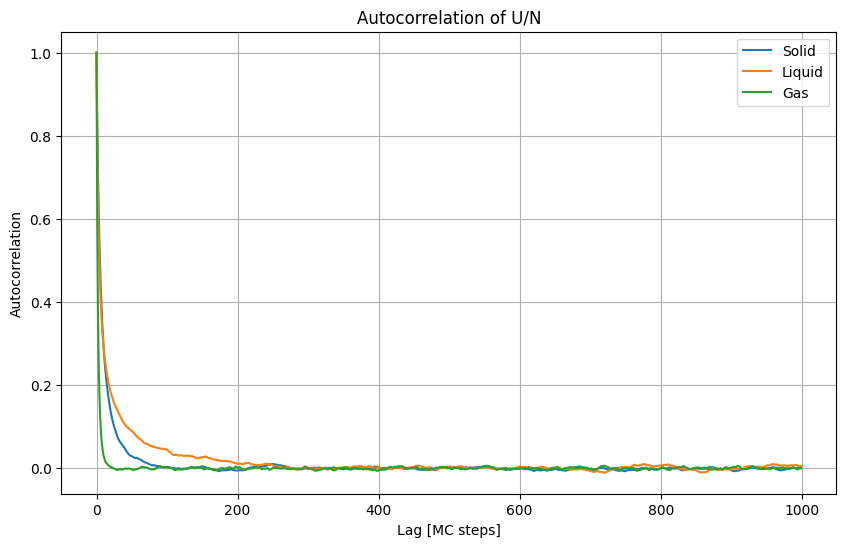

In [4]:
# Plot the autocorrelation functions for the three phases

def plot_correlazione(filenames, labels, title="Autocorrelation of U/N", max_lag=1000):
    plt.figure(figsize=(10, 6))

    # Compute and plot the autocorrelation for each input file
    for filename, label in zip(filenames, labels):
        corr = correlazione(filename)
        lag = np.arange(len(corr))

        # Display only the selected range of lags
        plt.plot(lag[:max_lag], corr[:max_lag], label=label)

    plt.xlabel("Lag [MC steps]")
    plt.ylabel("Autocorrelation")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# Input files and labels for the solid, liquid and gas phases
filenames = [ "NSL_SIMULATOR/OUTPUT/7.2/solid/potential_energy.dat", "NSL_SIMULATOR/OUTPUT/7.2/liquid/potential_energy.dat", "NSL_SIMULATOR/OUTPUT/7.2/gas/potential_energy.dat"]
labels = ["Solid", "Liquid", "Gas"]

plot_correlazione(filenames, labels, max_lag=1000)


Come atteso dal grafico si osserva innanzitutto il decadimento della funzione di autocorrelazione $C(\tau)$ all'aumentare del lag $\tau$. Si osserva inoltre che le curve di autocorrelazione partono correttamente da $1$, valore corrispondente al ritardo temporale $\tau= 0$.

Tra le tre fasi, la fase gassosa è quella per cui l'autocorrelazione decade più rapidamente: $C(\tau)$ si annulla già prima di circa $100$ step Monte Carlo. Questo comportamento è dovuto alla bassa densità del gas, per cui le particelle interagiscono raramente tra loro e le configurazioni successive risultano meno correlate.

Nel caso della fase solida, l'autocorrelazione decade anch'essa abbastanza rapidamente e può essere considerata trascurabile dopo circa $100$ step Monte Carlo.

La fase liquida, invece, mostra un decadimento più lento: risulta quindi la fase più autocorrelata tra quelle considerate. In questo caso si può considerare $C(\tau)$ trascurabile solo dopo circa $300$ step Monte Carlo.

In generale per considerare due misure indipendenti è un buon criterio aspettare un tempo $t$ (inteso come tempo Monte Carlo) che sia almeno $\gt 2t_{corr}$. Una scelta prudente è considerare $\gg 2t_{corr}$

In [5]:
import math

# Estimate the statistical uncertainty of a progressive average
def error(AV,AV2,n):
    if n==0:
        return 0 
    else:
        return math.sqrt((AV2[n] - AV[n]**2)/n)

# Evaluate the final statistical uncertainty as a function of the block length
def blocking (filename):

    # Read the instantaneous potential energy values
    data = np.loadtxt(filename, skiprows=1)
    U = data[:, 1]

    M = len(U)

    # Block lengths from 10 to 5000 simulation steps with increments of 50
    L_values = np.arange(10, 5000 + 1, 50)

    # Store the final progressive uncertainty obtained for each block length
    final_errors = np.zeros(len(L_values))

    for l_index, L in enumerate(L_values):

        # Number of blocks for the selected block length
        N = int(M/L)
        ave = np.zeros(N)
        av2 = np.zeros(N)

        # Compute the average potential energy in each block
        for i in range(N):
            sum = 0

            for j in range(L): 
                k = j+i*L
                sum += U[k]

            ave[i] = sum/L
            av2[i] = (ave[i])**2

        # Compute progressive averages and progressive squared averages
        sum_prog = np.cumsum(ave) / np.arange(1, N + 1)
        sum2_prog = np.cumsum(av2) / np.arange(1, N + 1)

        # Save the uncertainty associated with the final progressive average
        final_errors[l_index] = error(sum_prog, sum2_prog, N-1)

    return L_values , final_errors


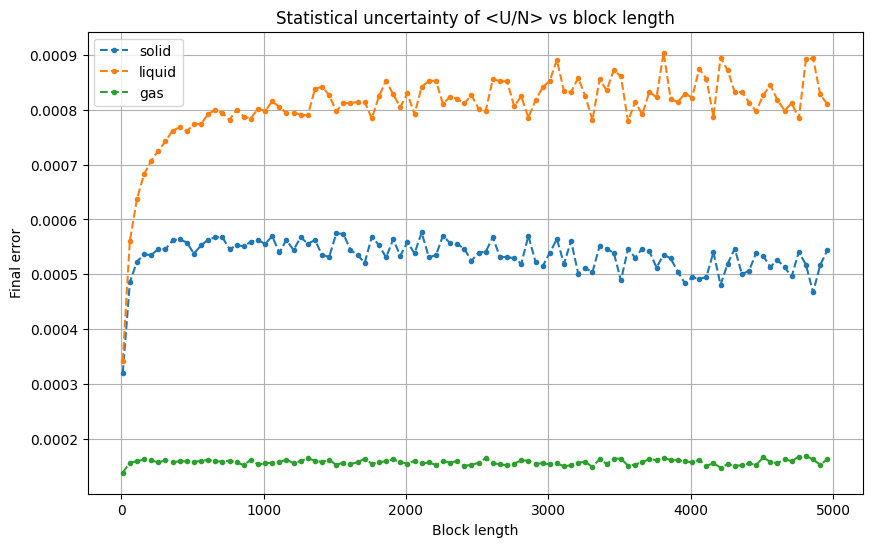

In [6]:
#Plot statistical uncertainty of U/N as a function of block length 
 
L_value_solid , final_errors_solid = blocking("NSL_SIMULATOR/OUTPUT/7.2/solid/potential_energy.dat")
L_value_liquid , final_errors_liquid = blocking("NSL_SIMULATOR/OUTPUT/7.2/liquid/potential_energy.dat")
L_value_gas , final_errors_gas = blocking("NSL_SIMULATOR/OUTPUT/7.2/gas/potential_energy.dat")

plt.figure(figsize=(10, 6))
plt.plot(L_value_solid, final_errors_solid, "o--", markersize = 3, label = "solid")
plt.plot(L_value_liquid, final_errors_liquid, "o--", markersize = 3, label = "liquid")
plt.plot(L_value_gas, final_errors_gas, "o--", markersize = 3, label = "gas")

plt.xlabel("Block length")
plt.ylabel("Final error")
plt.title("Statistical uncertainty of <U/N> vs block length")
plt.legend()
plt.grid()
plt.show()

Quanto detto prima risulta più chiaro guardando l'andamento dell'errore statistico in funzione della lunghezza $L$ di ogni blocco. 
In particolare i valori riportati nel grafico qui sopra corrispondono all'errore statistico del blocco **finale** (il più accurato) considerando valori di $L$ nel range $[10, 5000]$ con passi da $50$ steps.

In tutti e tre i casi è presente un transiente iniziale in cui l'errore aumenta con l'aumentare di $L$ prima di stabilizzarsi. Questo è dovuto al fatto che se si considerano blocchi troppo corti le misure all'interno del blocco sono più correlate, le medie di ogni blocco risultano quindi correlate e questo produce una sottostima dell'errore. Nel metodo delle medie a blocchi **l'errore sulla media** di ogni blocco viene stimato come $<\sigma_{blk}> = \sigma_{blk}/\sqrt{N}$ e questa stima è affidabile solo quando le medie dei diversi blocchi possono essere considerate circa indipendenti.
D’altra parte, i blocchi non devono essere scelti troppo lunghi, perché aumentando $L$ diminuisce il numero di blocchi disponibili e quindi peggiora la statistica.  Ciò si riflette in una maggiore oscillazione dell'errore all'aumentare di $L$, soprattuto evidente per fase liquida e solida ma presente comunque anche nella fase gassosa.

Per la fase gassosa si osserva che l'errore si stabilizza pressocché subito, prima di circa $100$ steps, coerentemente con il decadimento della funzione di autocorrelazione $C(\tau)$ che avveniva anch'esso prima di $100$ steps Monte Carlo. 
Per la fase solida si può notare che l'errore si stabilizza oscillando dopo circa $200$ / $250$ steps.
Coerentemente a prima anche in questo caso la fase liquida risulta la più correlata in quanto presenta un transiente più evidente. In questo caso l'errore si stabilizza oltre $500$ steps.

### <span style= "color: black" > Es07.3

Lo scopo di questo esercizio è aggiungere al codice C++ `system.cpp` il calcolo per ricavare i valori della funzione di distrbuzione radiale $g(r)$. 

In generale la funzione è definita come 

$$
g_N^{(n)} (\vec r_1, ...., \vec r_n) = \frac{\rho_N^{(n)}(\vec r_1, ...., \vec r_n)}{\prod_{i=1}^{n} \rho_N^{(1)}(\vec r_i)}
$$

e prende il nome di *funzione di distribuzione ad $n$ particelle/ correlazione ad $n$ corpi*. Essa dà la probabilità di trovare $n$ particelle in $\vec r_1, ...., \vec r_n$ rispetto alla probabilità di trovare $n$ particelle di un gas ideale (particelle indipendenti) in $\vec r_1, ...., \vec r_n$.

In questo esercizio si considera un sistema omogeneo ed isotropo e ci si concentra sul caso $n=2$, quindi su coppie di particelle a distanza $r$ => sulla distribuzione radiale $g(r)$. In questo caso $g(r)$ può essere calcolata con la seguente espressione:

$$
g(r) = \frac{1}{\rho N \Delta V(r)}
\left\langle
\sum_{i \ne j}^{N} \delta(r - r_{ij})
\right\rangle
$$

dove la $\delta(r - r_{ij})$ fa si che contribuiscano alla somma come $1$ solo quelle coppie $(i,j)$ per cui $r_{ij}=r$ e $\Delta V(r) = \frac{4\pi}{3}[((r+dr)^3-r^3)]$.

Per implementare questo conteggio nel codice si costruisce un istogramma di $100$ bins con estremi $[0, L_{\text{box}}/2]$ e si riempie il bin di $+2$ ogni volta che una coppia di particelle si trova ad una distanza che cade nel bin considerato. 



### <span style= "color: black" > Es07.4

A questo punto, dopo aver aggiornato il codice `system.cpp` con le correzioni di coda per l'energia potenziale e la pressione ed aver aggiunto il codice per il calcolo di $g(r)$, vengono ricavate queste quantità nelle tre differenti codizioni termodinamiche considerate prima.

Dopo aver equilibrato il sistema per $2000$ blocchi da $20$ steps, per tutte le 3 fasi viene eseguita una simulazione con $50$ blocchi da $2000$ steps ciascuno. I blocchi sono stati scelti di questa lunghezza in modo da essere sicuri di soddisfare la condizione $t_{MC}\gg t_c$.

Qui di seguito vengono riportati gli andamenti di $<U/N>$ e di $<P>$ in funzione del numero di blocchi e l'andamento di $g(r)$ in funzione della distanza $r$ fra le coppie di particelle con le rispettive barre di errore. 

In particolare si confrontano gli andamenti della distribuzione radiale $g(r)$ ricavati nel caso in cui la simulazione è stata eseguita con un algoritmo Monte Carlo (Metropolis) e nel caso di dinamica molecolare (Verlet) in condizioni termodinamiche simili. Per il caso di dinamica molecoolare sono state utiilizzate le configurazioni equilibrate ricavate nell'Esercitazione 4.

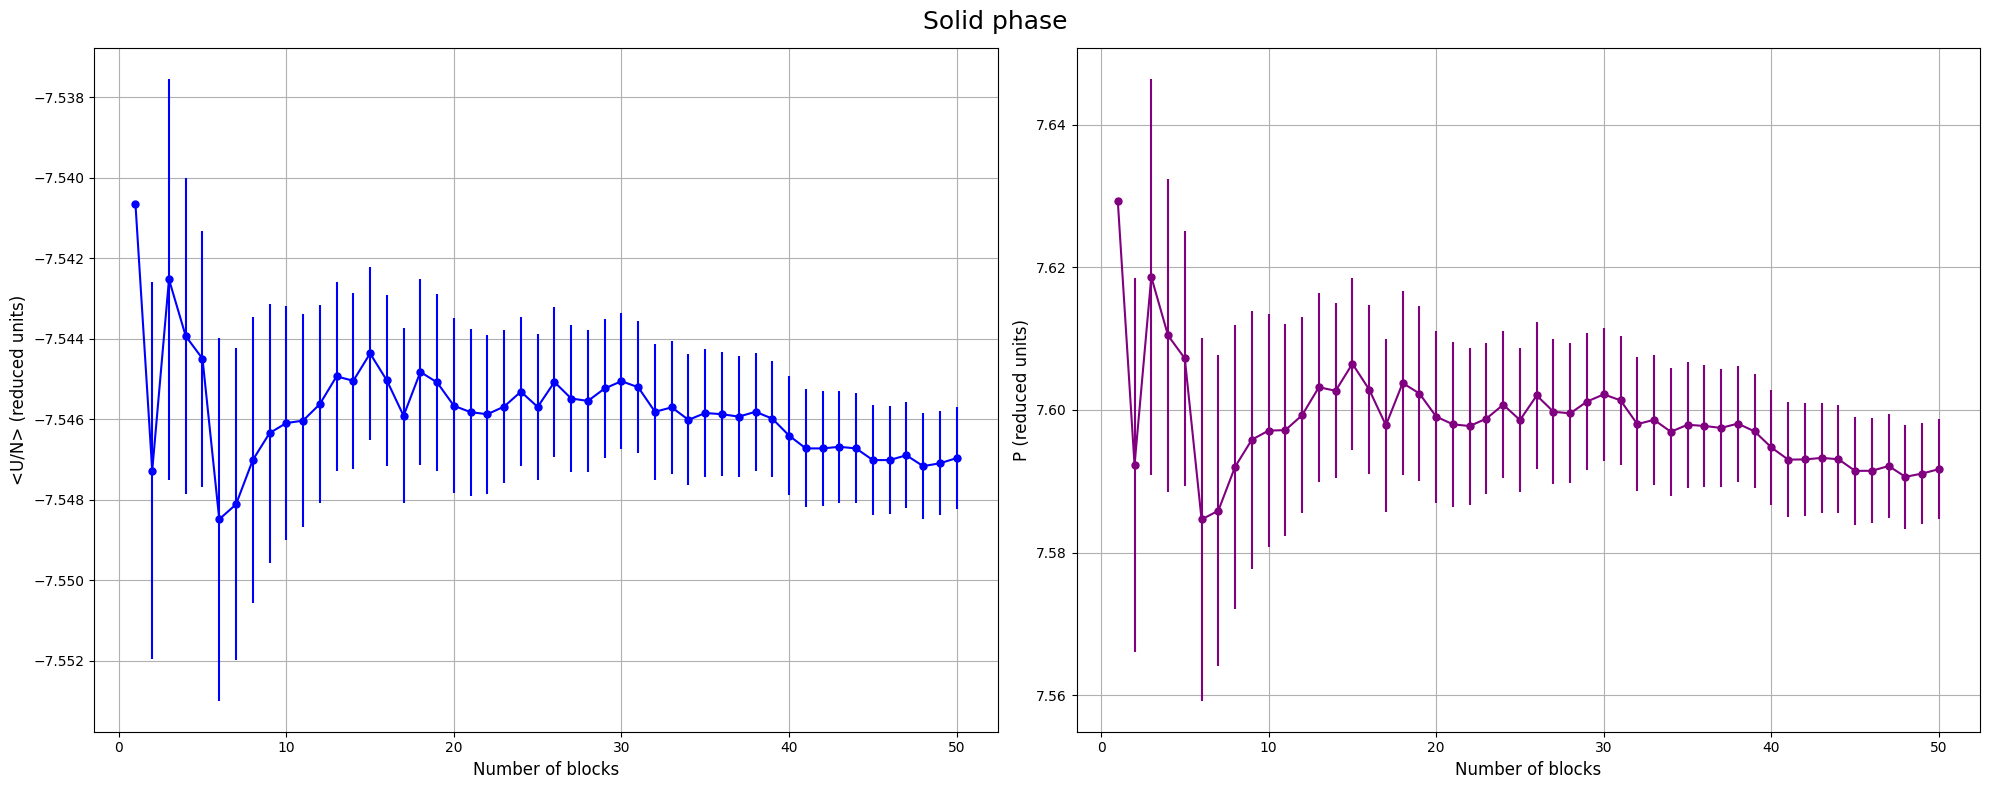

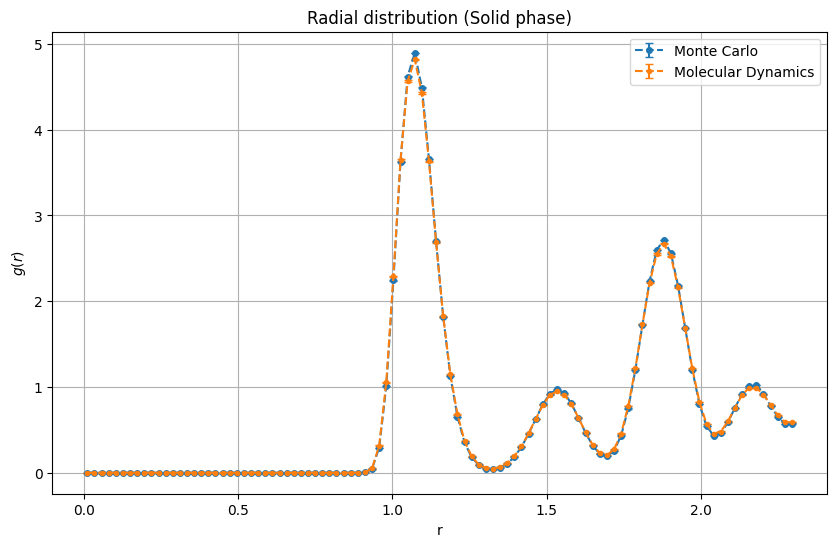

In [7]:
# Plot the progressive estimates of U/N and P for the solid phase
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

plot("NSL_SIMULATOR/OUTPUT/7.4/Solid/potential_energy.dat", "<U/N> (reduced units)", "blue", 2, steps_per_block=10, ax=axs[0])
plot("NSL_SIMULATOR/OUTPUT/7.4/Solid/pressure.dat", "P (reduced units)", "purple", 2, steps_per_block=10, ax=axs[1])

fig.suptitle("Solid phase", fontsize=18)
plt.tight_layout()
plt.show()

# Compare the radial distribution functions obtained with Monte Carlo and Molecular Dynamics
def plot_gofr (filename_MC, filename_MD, title):

    # Load the bin centers, g(r) values and statistical uncertainties
    plt.figure(figsize=(10, 6))
    x,y, error = np.loadtxt(filename_MC, usecols=(0,1,2), unpack=True)
    x_MD, y_MD, error_MD = np.loadtxt(filename_MD, usecols=(0, 1, 2), unpack=True)

    # Plot both estimates with error bars
    plt.errorbar(x,y,yerr=error,fmt = "o--", markersize = 4, capsize=3, label="Monte Carlo") #Creating a plot with error bars
    plt.errorbar(x_MD, y_MD, yerr=error_MD, fmt="o--", markersize=3, capsize=3, label="Molecular Dynamics")
    plt.xlabel('r') 
    plt.ylabel("$g(r)$")
    plt.legend()
    plt.grid(True)
    plt.title(title)
    plt.show()

# Solid phase
plot_gofr("NSL_SIMULATOR/OUTPUT/7.4/Solid/gofr.dat", "NSL_SIMULATOR/OUTPUT/Risultati_Verlet/solid_gofr.dat", "Radial distribution (Solid phase)")

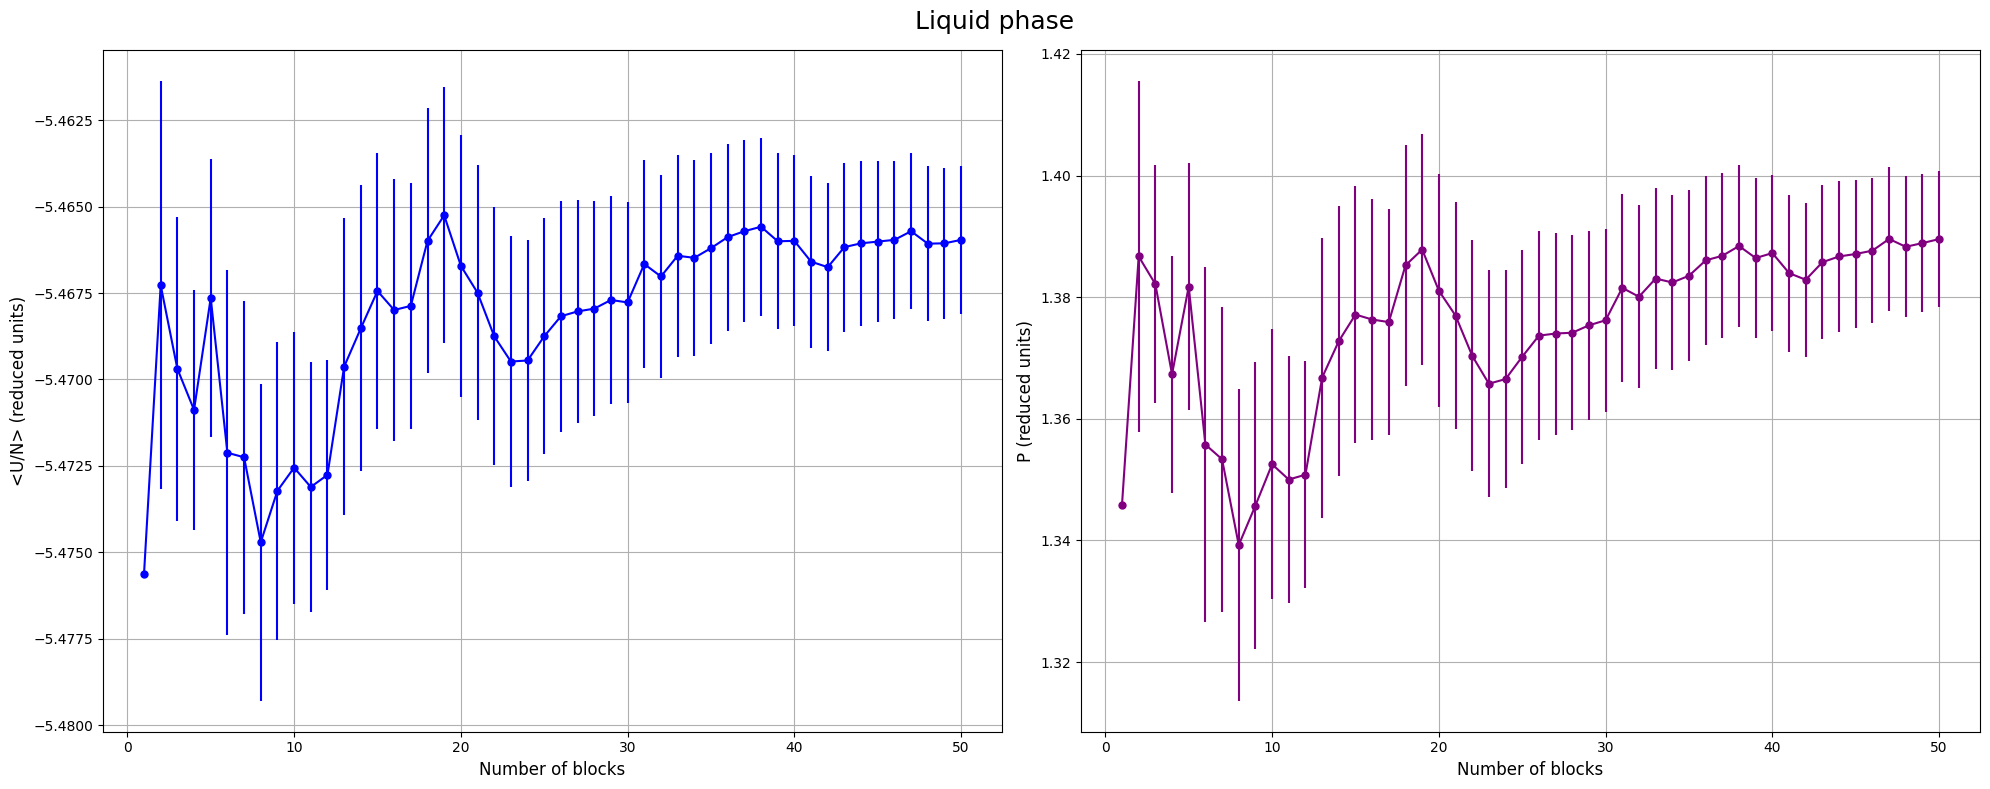

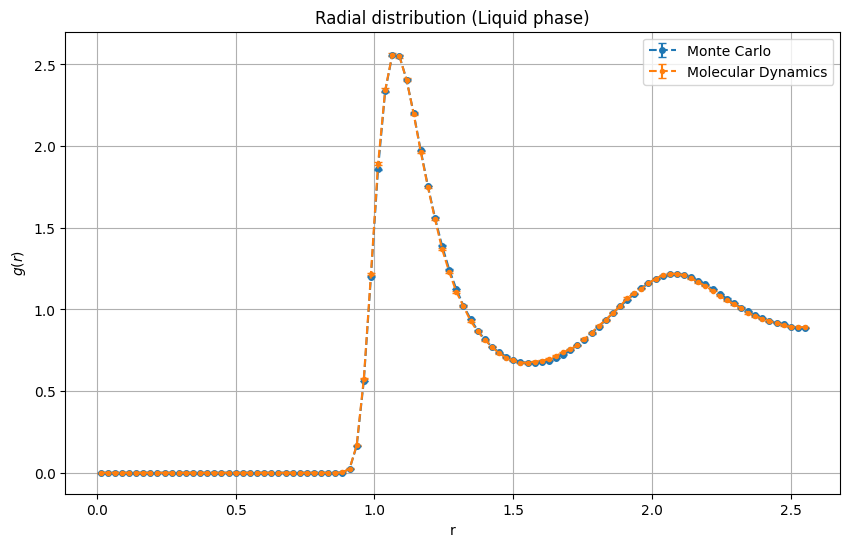

In [8]:
# Liquid phase

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

plot("NSL_SIMULATOR/OUTPUT/7.4/Liquid/potential_energy.dat", "<U/N> (reduced units)", "blue", 2, steps_per_block=10, ax=axs[0])
plot("NSL_SIMULATOR/OUTPUT/7.4/Liquid/pressure.dat", "P (reduced units)", "purple", 2, steps_per_block=10, ax=axs[1])

fig.suptitle("Liquid phase", fontsize=18)
plt.tight_layout()
plt.show()

plot_gofr("NSL_SIMULATOR/OUTPUT/7.4/Liquid/gofr.dat", "NSL_SIMULATOR/OUTPUT/Risultati_Verlet/liquid_gofr.dat", "Radial distribution (Liquid phase)")

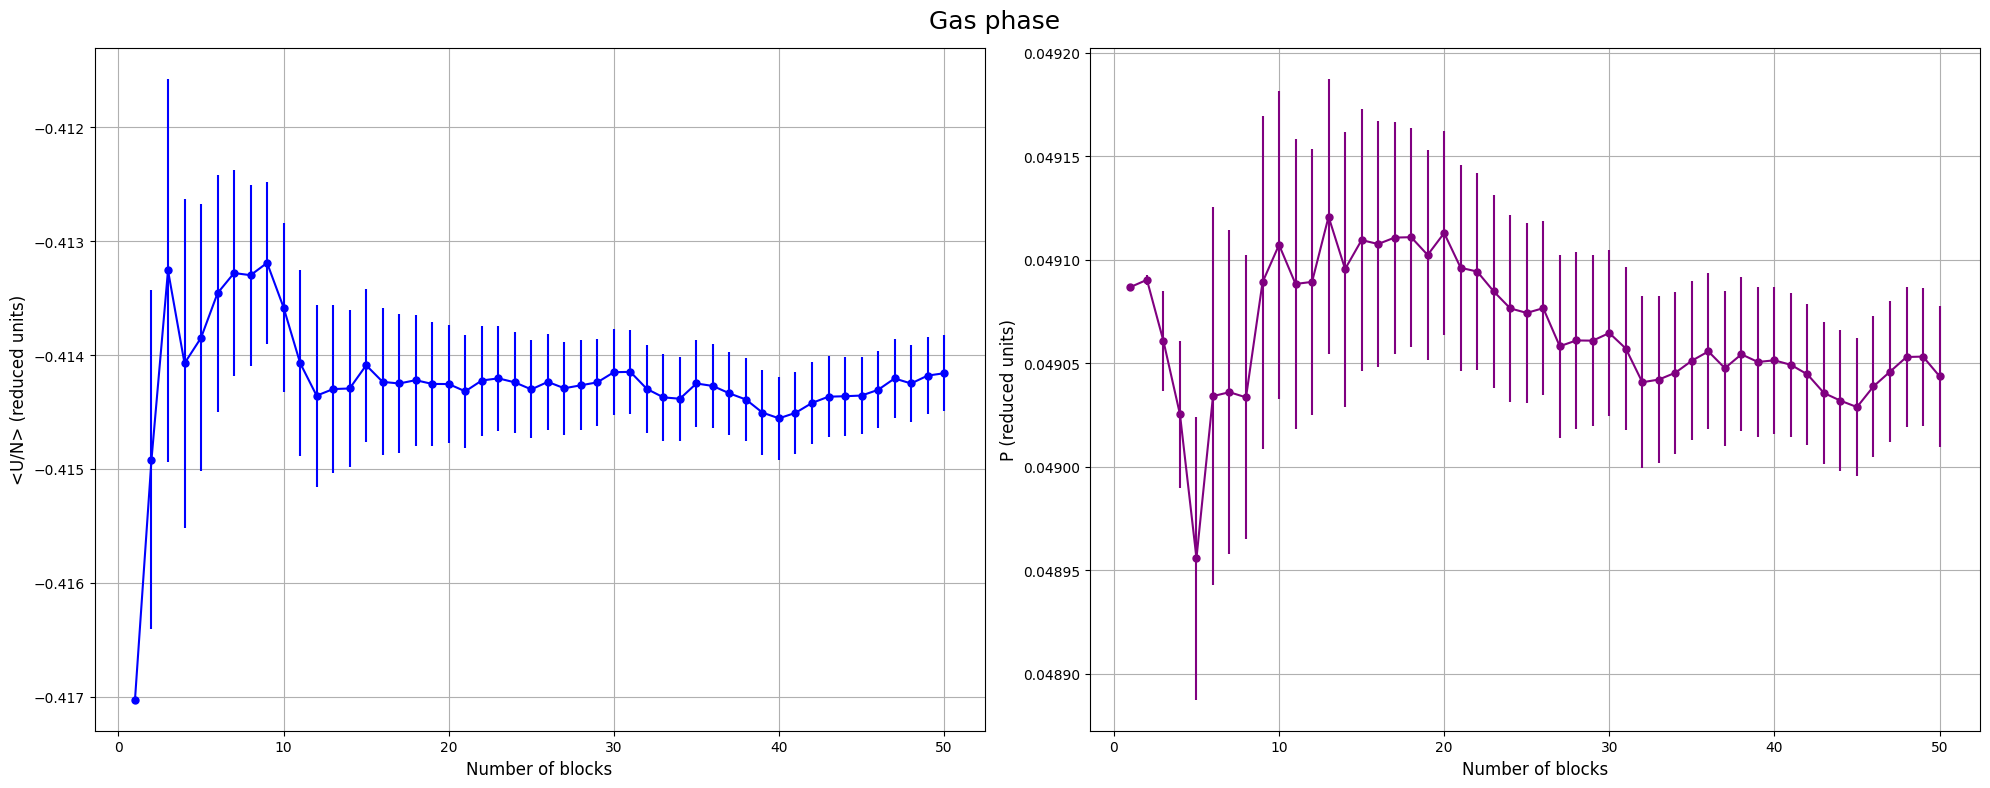

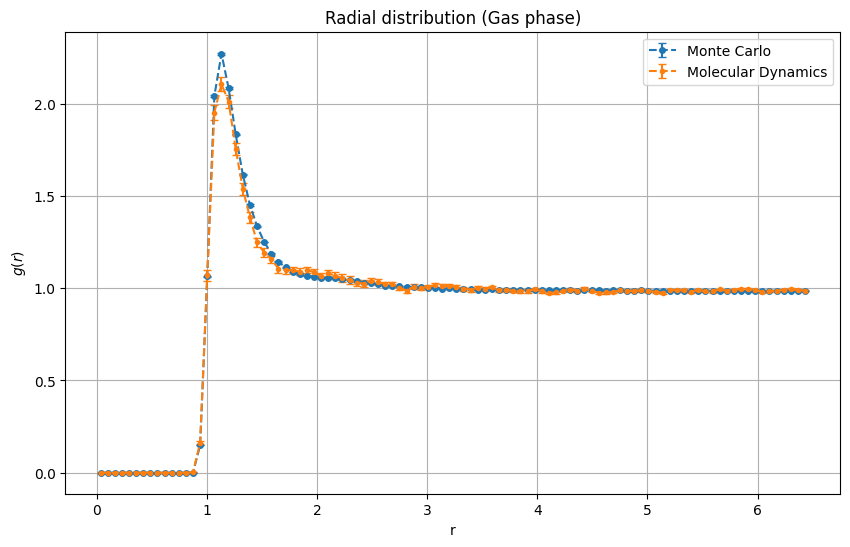

In [9]:
# Gas phase
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

plot("NSL_SIMULATOR/OUTPUT/7.4/Gas/potential_energy.dat", "<U/N> (reduced units)", "blue", 2, steps_per_block=10, ax=axs[0])
plot("NSL_SIMULATOR/OUTPUT/7.4/Gas/pressure.dat", "P (reduced units)", "purple", 2, steps_per_block=10, ax=axs[1])

fig.suptitle("Gas phase", fontsize=18)
plt.tight_layout()
plt.show()

plot_gofr("NSL_SIMULATOR/OUTPUT/7.4/Gas/gofr.dat", "NSL_SIMULATOR/OUTPUT/Risultati_Verlet/gas_gofr.dat", "Radial distribution (Gas phase)")

Per tutti e tre i casi si trova quasi perfetto accordo tra i valori di $g(r)$ ricavati dalla simulazione di dinamica molecolare e dalla simulazione Monte Carlo.